<a href="https://colab.research.google.com/github/cvilelahep/SNDLHC_ATLAS_PIC1_2026/blob/main/SNDLHC_ATLAS_PIC1_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install software
%pip install uproot
import uproot
%pip install matplotlib
import matplotlib.pyplot as plt

In [2]:
# Get the data
!rm -r *
!wget https://cernbox.cern.ch/remote.php/dav/public-files/mr73X9rfeNu2Sjn/SignalPOWHEG/pwgevents-PYTHIA-filtered.root
!wget https://cernbox.cern.ch/remote.php/dav/public-files/mr73X9rfeNu2Sjn/BackgroundEPOSLHC/epos_lhc_14TeV.root

--2026-03-06 10:51:27--  https://cernbox.cern.ch/remote.php/dav/public-files/mr73X9rfeNu2Sjn/SignalPOWHEG/pwgevents-PYTHIA-filtered.root
Resolving cernbox.cern.ch (cernbox.cern.ch)... 128.142.53.35, 137.138.120.151, 128.142.53.28, ...
Connecting to cernbox.cern.ch (cernbox.cern.ch)|128.142.53.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 216162222 (206M) [application/octet-stream]
Saving to: ‘pwgevents-PYTHIA-filtered.root’

pwgevents-PYTHIA-fi 100%[===================>] 206.15M   232KB/s    in 9m 1s   

2026-03-06 11:00:29 (390 KB/s) - ‘pwgevents-PYTHIA-filtered.root’ saved [216162222/216162222]

--2026-03-06 11:00:29--  https://cernbox.cern.ch/remote.php/dav/public-files/mr73X9rfeNu2Sjn/BackgroundEPOSLHC/epos_lhc_14TeV.root
Resolving cernbox.cern.ch (cernbox.cern.ch)... 128.142.170.17, 128.142.53.28, 128.142.53.35, ...
Connecting to cernbox.cern.ch (cernbox.cern.ch)|128.142.170.17|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length:

In [5]:
# Look at the file contents
signal_events = uproot.open("pwgevents-PYTHIA-filtered.root:Events")
background_events = uproot.open("epos_lhc_14TeV.root:Events")

# Tree branches
signal_events.show()


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
npdg                 | int32_t                  | AsDtype('>i4')
pdg                  | int64_t[]                | AsJagged(AsDtype('>i8'))
ncharge              | int32_t                  | AsDtype('>i4')
charge               | double[]                 | AsJagged(AsDtype('>f8'))
npx                  | int32_t                  | AsDtype('>i4')
px                   | double[]                 | AsJagged(AsDtype('>f8'))
npy                  | int32_t                  | AsDtype('>i4')
py                   | double[]                 | AsJagged(AsDtype('>f8'))
npz                  | int32_t                  | AsDtype('>i4')
pz                   | double[]                 | AsJagged(AsDtype('>f8'))
neta                 | int32_t                  | AsDtype('>i4')
eta                  | double[]                 | AsJagged(AsDtype('>f8')

In [31]:
[this_pdg[0] for this_pdg in signal_events.arrays(["pdg"])["pdg"] if len(this_pdg) > 0]

[np.int64(211),
 np.int64(22),
 np.int64(22),
 np.int64(211),
 np.int64(2212),
 np.int64(-211),
 np.int64(211),
 np.int64(2212),
 np.int64(-321),
 np.int64(211),
 np.int64(211),
 np.int64(-211),
 np.int64(-2212),
 np.int64(-2112),
 np.int64(-211),
 np.int64(22),
 np.int64(2112),
 np.int64(-2212),
 np.int64(-321),
 np.int64(-2212),
 np.int64(2112),
 np.int64(211),
 np.int64(-211),
 np.int64(-211),
 np.int64(-211),
 np.int64(211),
 np.int64(2212),
 np.int64(211),
 np.int64(-211),
 np.int64(-211),
 np.int64(2212),
 np.int64(-211),
 np.int64(130),
 np.int64(2212),
 np.int64(-211),
 np.int64(22),
 np.int64(130),
 np.int64(211),
 np.int64(-211),
 np.int64(211),
 np.int64(-211),
 np.int64(211),
 np.int64(22),
 np.int64(211),
 np.int64(2112),
 np.int64(-2212),
 np.int64(211),
 np.int64(-321),
 np.int64(-2112),
 np.int64(-211),
 np.int64(321),
 np.int64(-211),
 np.int64(211),
 np.int64(211),
 np.int64(211),
 np.int64(-211),
 np.int64(2212),
 np.int64(-211),
 np.int64(211),
 np.int64(130),
 np.i

(array([532., 553., 549., 544., 513., 539., 551., 521., 531., 495., 553.,
        540., 605., 595., 539., 573., 570., 576., 551., 568., 592., 585.,
        576., 551., 609., 576., 555., 560., 577., 563., 582., 593., 575.,
        582., 543., 573., 577., 558., 559., 533., 536., 562., 579., 611.,
        590., 569., 569., 564., 560., 562., 551., 566., 561., 568., 610.,
        574., 585., 573., 572., 576., 599., 558., 606., 549., 548., 579.,
        561., 543., 566., 525., 514., 517., 530., 527., 540., 539., 547.,
        530., 517., 532.]),
 array([-4. , -3.9, -3.8, -3.7, -3.6, -3.5, -3.4, -3.3, -3.2, -3.1, -3. ,
        -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2.3, -2.2, -2.1, -2. , -1.9,
        -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8,
        -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,
         0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,
         1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,
         2

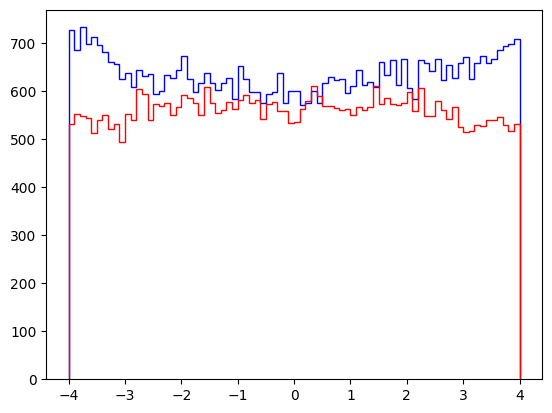

In [35]:
plt.figure()
plt.hist([this_pdg[0] for this_pdg in signal_events.arrays(["eta"])["eta"] if len(this_pdg) > 0], bins = 80, range = (-4, 4), color = "b", histtype = "step")
plt.hist([this_pdg[0] for this_pdg in background_events.arrays(["eta"])["eta"] if len(this_pdg) > 0], bins = 80, range = (-4, 4), color = "r", histtype = "step")